# Оценка мотивационных анкет кандидатов

### Целевая метрика
Основная метрика качества — **QWK (Quadratic Weighted Kappa)**. Она идеально подходит для задач автоматического оценивания эссе (Automated Essay Scoring), так как штрафует модель пропорционально квадрату ошибки (ошибка между 0 и 3 баллами штрафуется значительно сильнее, чем между 2 и 3). Дополнительно отслеживается **MAE** для контроля среднего абсолютного отклонения в баллах.

## 1. Импорты


In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.2 MB/s eta 0:00:00


In [2]:
import torch
import sys
import importlib
import re
import optuna
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, HuberRegressor
from scipy.optimize import minimize
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import mean_absolute_error, mean_squared_error, cohen_kappa_score, accuracy_score, f1_score, confusion_matrix
warnings.filterwarnings("ignore")

In [3]:
colors = ["#4C6EF5", "#40C057", "#FA5252", "#7950F2", "#FD7E14"]
threshold = 6
fold_out = 5
fold_in = 3
ridge_alpha = [0.1, 1.0, 10.0, 100.0]
enseble = (0.4, 0.6)
questions = [("q1", "score1", "Q1: Почему именно вы?"),("q2", "score2", "Q2: Применение знаний"),("q3", "score3", "Q3: Задача сверх обязанностей"),]

## 2. Загрузка данных

Сразу преобразую колонки,которые были заполнены , или . и другими значениями,которые можно считать как пропуск в Nan

In [4]:
df = pd.read_excel('tests.xlsx', engine="openpyxl").replace(r"^\s*([.\-*xX]|норм|Норм|НОРМ)\s*$", np.nan, regex=True)
df.columns = ["id", "q1", "score1", "q2", "score2", "q3", "score3", "total"]

train = df[df["id"].str.startswith("train")].copy().reset_index(drop=True)
val= df[df["id"].str.startswith("val")].copy().reset_index(drop=True)
val['id'] = [f"val_{i}" for i in range(len(val))]

print(len(df))
print(len(train))
print(len(val))
train[["id", "q1", "score1", "q2", "score2", "q3", "score3", "total"]].head(4)

802
651
151


,id,q1,score1,q2,score2,q3,score3,total
0,train_0,для анализа массивов данных необходимых в работе,2.0,для анализа массивов данных необходимых в работе,2.0,"стараюсь всегда брать задачи, выполнение котор...",2.0,6.0
1,train_1,Буду использовать полученные знания в работе д...,2.0,Автоматизирую процесс сбора данных и дальнейше...,2.0,Задача по анализу кода и содержанию пакетов - ...,1.5,5.5
2,train_2,хочу стать топовым программистом во всём мире ...,1.5,изучаю программирование,1.5,NaN,0.0,3.0
3,train_3,"Смогу применить знания в своей професси, получ...",2.0,Буду заниматься автоматизацией и отладкой рабо...,2.5,Как и указано выше мне интересно улучшить суще...,2.5,7.0


In [5]:
val.iloc[84]

,84
id,val_84
q1,NaN
score1,NaN
q2,NaN
score2,NaN
q3,NaN
score3,NaN
total,NaN


Статистика оценок в тренировочной выборке

In [6]:
score_stats = train[["score1", "score2", "score3", "total"]].describe().round(2)
score_stats.index.name = "метрика"
score_stats

,score1,score2,score3,total
метрика,,,,
count,651.00,651.00,651.00,651.00
mean,1.42,1.70,1.72,4.84
std,0.80,0.87,0.90,2.08
min,0.00,0.00,0.00,0.00
25%,1.00,1.00,1.00,3.00
50%,1.00,2.00,2.00,5.00
75%,2.00,2.00,2.00,6.00
max,3.00,3.00,3.00,9.00


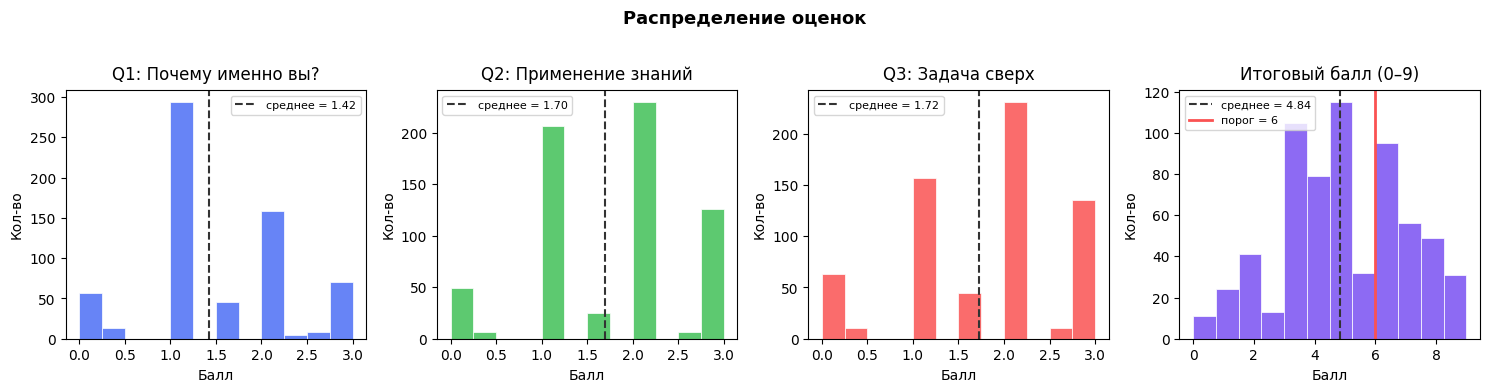

Доля кандидатов с итогом ≥ 6: 35.5%  (231 из 651)


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
fig.suptitle("Распределение оценок", fontsize=13, fontweight="bold", y=1.02)
score_cols  = ["score1", "score2", "score3", "total"]
q_titles = ["Q1: Почему именно вы?", "Q2: Применение знаний","Q3: Задача сверх", "Итоговый балл (0–9)"]

for ax, col, title, color in zip(axes, score_cols, q_titles, colors):
    vals = train[col].dropna()
    n_missing = train[col].isna().sum()
    ax.hist(vals, bins=12, color=color, alpha=0.85, edgecolor="white", linewidth=0.6)
    ax.axvline(vals.mean(), color="#333", linestyle="--", linewidth=1.5, label=f"среднее = {vals.mean():.2f}")
    if col == "total":
        ax.axvline(threshold, color="#FA5252", linestyle="-", linewidth=2, label=f"порог = {threshold}")
    ax.set_title(title, pad=8)
    ax.set_xlabel("Балл")
    ax.set_ylabel("Кол-во")
    if n_missing:
        ax.text(0.97, 0.97, f"пропуски: {n_missing}", transform=ax.transAxes, ha="right", va="top", fontsize=8, color="#FA5252")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
pass_rate = (train["total"] >= threshold).mean()
print(f"Доля кандидатов с итогом ≥ {threshold}: {pass_rate:.1%}  ({int(pass_rate*len(train))} из {len(train)})")


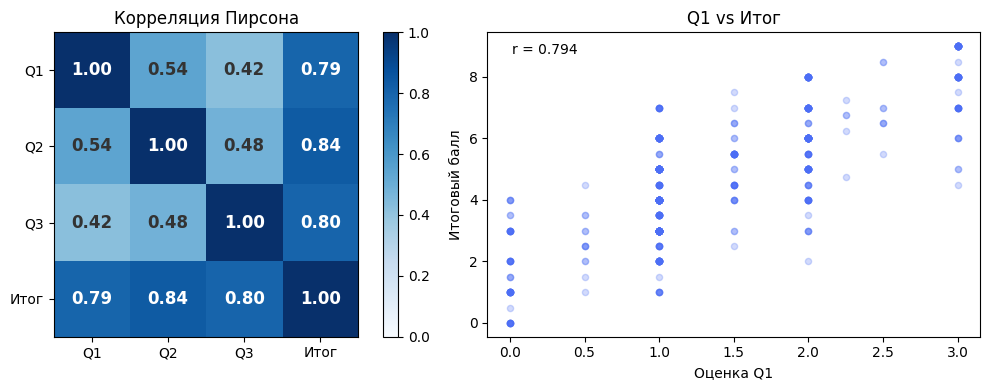

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
corr = train[["score1", "score2", "score3", "total"]].corr()
im = axes[0].imshow(corr.values, cmap="Blues", vmin=0, vmax=1)
labels = ["Q1", "Q2", "Q3", "Итог"]
axes[0].set_xticks(range(4)); axes[0].set_yticks(range(4))
axes[0].set_xticklabels(labels); axes[0].set_yticklabels(labels)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                     fontsize=12, fontweight="bold",
                     color="white" if corr.iloc[i,j] > 0.6 else "#333")
plt.colorbar(im, ax=axes[0], fraction=0.04)
axes[0].set_title("Корреляция Пирсона")
axes[1].scatter(train["score1"], train["total"], alpha=0.25, s=20, color=colors[0])
axes[1].set_xlabel("Оценка Q1"); axes[1].set_ylabel("Итоговый балл")
axes[1].set_title("Q1 vs Итог")
r, _ = pearsonr(train["score1"].fillna(0), train["total"].fillna(0))
axes[1].text(0.05, 0.93, f"r = {r:.3f}", transform=axes[1].transAxes, fontsize=10)
plt.tight_layout()
plt.show()

## 3. Обработка пропусков

Так как при импорте я заранее заменил значения,которые считал пропусками на nan,то тут будет проще посчитать количество пропусков через isnull.
Для текстовых пропусков заменяем на `""` + отдельный признак `is_missing_q{N}`.


In [9]:
train.isnull().sum()

,0
id,0
q1,1
score1,0
q2,3
score2,0
q3,20
score3,0
total,0


In [10]:
val.isnull().sum()

,0
id,0
q1,1
score1,151
q2,1
score2,151
q3,4
score3,151
total,151


In [11]:
def clean_text(text) -> str:
    """
    Очистка текста:
    - NaN / None → пустая строка
    - Удаление лишних пробелов и спецсимволов
    - Нормализация переносов строк
    """
    if pd.isna(text) or text is None:
        return ""
    text = str(text).strip()
    text = re.sub(r"[\r\n]+", " ", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Применяет очистку текстов и добавляет бинарные флаги пропусков.
    Флаг is_missing_q{N} = 1, если кандидат не заполнил ответ.
    """
    df = df.copy()
    for q_col in ["q1", "q2", "q3"]:
        suffix = q_col[-1]
        df[f"is_missing_{q_col}"] = df[q_col].isna().astype(int)
        df[q_col] = df[q_col].apply(clean_text)
    return df

train = preprocess(train)
val = preprocess(val)
n_missing_train = sum(train[f"is_missing_q{i}"].sum() for i in [1,2,3])
n_missing_val = sum(val[f"is_missing_q{i}"].sum() for i in [1,2,3])
print(f"Пропуски текстов в train: {n_missing_train}")
print(f"Пропуски текстов в val: {n_missing_val}")
print("Пример очищенного текста (q1, строка 0)")
train['q1'][0][:100]

Пропуски текстов в train: 24
Пропуски текстов в val: 6
Пример очищенного текста (q1, строка 0)


'для анализа массивов данных необходимых в работе'

## 4. Разбиение на признаки

Для каждого вопроса мы готовим свой набор признаков, чтобы модель лучше понимала особенности каждого задания. Используем три вида данных:Сочетания букв (2000 признаков) берем кусочки слов по 3–4 буквы. Это спасает, если человек написал ответ с опечатками или ошибками.Отдельные слова (2000 признаков) классический подсчет важных слов из текста.Статистика текста (9 признаков) длина ответа, структура предложений, есть ли цифры и заполнено ли вообще поле.

In [12]:
def text_features(texts: pd.Series, is_missing_flags: pd.Series) -> np.ndarray:
    """
    9 ручных признаков текста:
      0. n_chars           — длина текста в символах
      1. n_words           — количество слов
      2. n_unique_words    — количество уникальных слов
      3. n_sentences       — количество предложений
      4. has_numbers       — есть ли числовые данные (1/0)
      5. avg_word_len      — средняя длина слова
      6. lexical_diversity — n_unique / n_words (лексическое разнообразие)
      7. words_per_sent    — среднее число слов на предложение
      8. is_missing        — флаг: текст отсутствовал (1/0)
    """
    feats = []
    for t, missing in zip(texts, is_missing_flags):
        words = re.findall(r"[а-яёa-z]+", t.lower())
        sents = [s for s in re.split(r"[.!?]+", t) if s.strip()]
        n_w   = len(words)
        n_u   = len(set(words))
        n_s   = max(len(sents), 1)
        feats.append([
            len(t),
            n_w,
            n_u,
            n_s,
            int(bool(re.search(r"\d+", t))),
            np.mean([len(w) for w in words]) if words else 0,
            n_u / n_w if n_w > 0 else 0,
            n_w / n_s,
            int(missing),
        ])
    return np.array(feats, dtype=np.float32)

def build_tfidf(texts: pd.Series):
    """Обучить TF-IDF (char n-gram + word unigram) на тренировочных текстах."""
    char_v = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 4),
        max_features=2000, sublinear_tf=True
    )
    word_v = TfidfVectorizer(
        analyzer="word", ngram_range=(1, 1),
        max_features=2000, sublinear_tf=True, min_df=2
    )
    char_v.fit(texts)
    word_v.fit(texts)
    return char_v, word_v

def encode(texts: pd.Series, missing_flags: pd.Series,
           char_v, word_v) -> np.ndarray:
    """Объединить TF-IDF матрицы и ручные признаки в плотный массив."""
    char_mat = char_v.transform(texts).toarray()
    word_mat = word_v.transform(texts).toarray()
    hand_mat = text_features(texts, missing_flags)
    return np.hstack([char_mat, word_mat, hand_mat])

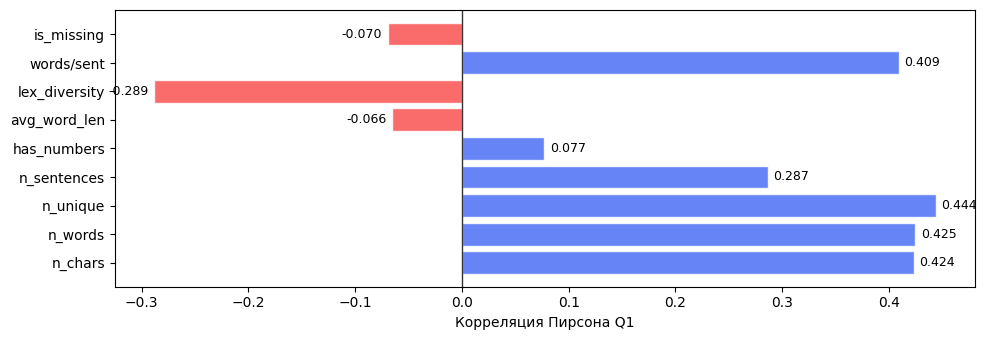

In [13]:
miss = train["is_missing_q1"].fillna(0)
hf = text_features(train["q1"], miss)
y = train["score1"].fillna(0).values
names = ["n_chars", "n_words", "n_unique", "n_sentences", "has_numbers", "avg_word_len", "lex_diversity", "words/sent", "is_missing"]
corrs = [np.corrcoef(hf[:, i], y)[0, 1] for i in range(9)]
fig, ax = plt.subplots(figsize=(10, 3.5))
colors_bar = [colors[2] if c < 0 else colors[0] for c in corrs]
bars = ax.barh(names, corrs, color=colors_bar, alpha=0.85, edgecolor="white")
ax.axvline(0, color="#333", linewidth=1)
for bar, v in zip(bars, corrs):
    ax.text(v + (0.005 if v >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.set_xlabel("Корреляция Пирсона Q1")
plt.tight_layout()
plt.show()

## 5. Метрики качества

Основная метрика для проверки - QWK (Quadratic Weighted Kappa). Это стандартный способ оценки эссе. Она работает лучше обычной ошибки (MAE), потому что сильнее штрафует за грубые промахи (ошибка в 3 балла гораздо хуже ошибки в 1 балл). Показывает, насколько модель «согласна» с оценками реального человека.

Ориентиры для QWK:
- Ниже 0.4 - плохо
- 0.4 - 0.6 - средне
- 0.6 - 0.8 - хороший результат
- Выше 0.8 - отлично

Дополнительно смотрим на MAE (среднюю абсолютную ошибку), она просто и понятно показывает, на сколько баллов в среднем ошибается модель.

In [14]:
def qwk(y_true: np.ndarray, y_pred: np.ndarray, max_score: int = 3) -> float:
    """
    Quadratic Weighted Kappa.
    Округляет предсказания до целых перед вычислением.
    Возвращает NaN если все значения одинаковы.
    """
    y_r = np.round(y_true).astype(int).clip(0, max_score)
    y_p = np.round(y_pred).astype(int).clip(0, max_score)
    try:
        return cohen_kappa_score(y_r, y_p, weights="quadratic")
    except Exception:
        return float("nan")

def metrics_report(y_true: np.ndarray, y_pred: np.ndarray,
                   label: str, max_score: int = 3) -> dict:
    """Вычисляет и печатает полный набор метрик."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    k = qwk(y_true, y_pred, max_score)
    r, _ = pearsonr(y_true, y_pred)
    print(f"MAE = {mae:.3f}")
    print(f"RMSE = {rmse:.3f}")
    print(f"QWK = {k:.3f}")
    print(f"Pearson = {r:.3f}")
    return {"mae": mae, "rmse": rmse, "qwk": k, "pearson": r}

## 6. K-Fold обучение

При небольшом датасете в данном случае 651,данных становится не достаточно для качественного обучения. Поэтому мы бьем данные на части фолды и учим модель по кругу: на нескольких частях она обучается, а на оставшейся - проверяет себя. Процесс повторяется несколько раз, пока каждый кусочек данных не побывает в роли проверки.

In [15]:
models_final = {}
tfidf_store = {}
fold_mae_log = {q_name: [] for _, _, q_name in questions}
overall_mae_log = {}

all_oof_tfidf = np.zeros(len(train))
fold_outf = KFold(n_splits=fold_out, shuffle=True, random_state=42)

if 'X_bert_base_train' not in locals() and 'X_bert_base_train' not in globals():
    X_bert_base_train = None

for q_col, s_col, q_name in questions:
    y = train[s_col].fillna(0).values
    miss_flags = train[f"is_missing_{q_col}"]
    texts = train[q_col]
    oof_ridge = np.zeros(len(y))
    oof_gbm = np.zeros(len(y))
    best_alphas_list = []
    fold_w_ridge = []
    fold_w_gbm = []
    for fold, (tr_i, val_i) in enumerate(fold_outf.split(texts)):
        char_v_fold, word_v_fold = build_tfidf(texts.iloc[tr_i])
        X_tr = encode(texts.iloc[tr_i], miss_flags.iloc[tr_i], char_v_fold, word_v_fold)
        X_val = encode(texts.iloc[val_i], miss_flags.iloc[val_i], char_v_fold, word_v_fold)
        y_tr, y_val = y[tr_i], y[val_i]
        fold_inf = KFold(n_splits=fold_in, shuffle=True, random_state=fold)
        best_alpha, best_mae_inner = ridge_alpha[1], 999.0
        for alpha in ridge_alpha:
            inner_maes = []
            for ti, vi in fold_inf.split(X_tr):
                r = Ridge(alpha=alpha)
                r.fit(X_tr[ti], y_tr[ti])
                p = np.clip(r.predict(X_tr[vi]), 0, 3)
                inner_maes.append(mean_absolute_error(y_tr[vi], p))
            if np.mean(inner_maes) < best_mae_inner:
                best_mae_inner = np.mean(inner_maes)
                best_alpha = alpha

        best_alphas_list.append(best_alpha)
        ridge = Ridge(alpha=best_alpha)
        gbm = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=42)
        ridge.fit(X_tr, y_tr)
        gbm.fit(X_tr, y_tr)
        preds_ridge_tr = ridge.predict(X_tr)
        preds_gbm_tr = gbm.predict(X_tr)
        preds_ridge_val = ridge.predict(X_val)
        preds_gbm_val = gbm.predict(X_val)
        oof_ridge[val_i] = preds_ridge_val
        oof_gbm[val_i] = preds_gbm_val
        def objective_fold_weights(trial):
            w_r = trial.suggest_float("w_r", 0.0, 1.0)
            w_g = trial.suggest_float("w_g", 0.0, 1.0)
            preds_blend_tr = np.clip(w_r * preds_ridge_tr + w_g * preds_gbm_tr, 0, 3)
            return qwk(y_tr, preds_blend_tr, 3)

        study_fold_w = optuna.create_study(direction="maximize")
        study_fold_w.optimize(objective_fold_weights, n_trials=30)
        best_fold_w = study_fold_w.best_params

        fold_w_ridge.append(best_fold_w["w_r"])
        fold_w_gbm.append(best_fold_w["w_g"])
        fold_preds = np.clip(best_fold_w["w_r"] * preds_ridge_val + best_fold_w["w_g"] * preds_gbm_val, 0, 3)
        fold_mae_log[q_name].append(mean_absolute_error(y_val, fold_preds))
    final_w_ridge = np.mean(fold_w_ridge)
    final_w_gbm = np.mean(fold_w_gbm)
    char_v_f, word_v_f = build_tfidf(texts)
    X_full = encode(texts, miss_flags, char_v_f, word_v_f)
    final_alpha = np.mean(best_alphas_list)
    ridge_f = Ridge(alpha=final_alpha)
    gbm_f = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=42)
    ridge_f.fit(X_full, y)
    gbm_f.fit(X_full, y)
    models_final[q_col] = (ridge_f, gbm_f, final_w_ridge, final_w_gbm)
    tfidf_store[q_col] = (char_v_f, word_v_f)
    oof_final_q = np.clip(final_w_ridge * oof_ridge + final_w_gbm * oof_gbm, 0, 3)
    overall_mae_log[q_name] = mean_absolute_error(y, oof_final_q)
    all_oof_tfidf += oof_final_q
    print(f"[{q_name}] TF-IDF Ridge={final_w_ridge:.2f}, GBM={final_w_gbm:.2f}, QWK: {qwk(y, oof_final_q, 3):.3f}")
all_oof = all_oof_tfidf

total_true = train["total"].fillna(0).values
print(f"MAE: {mean_absolute_error(total_true, all_oof_tfidf):.3f}, QWK: {qwk(total_true, all_oof_tfidf, 9):.3f}")

[I 2026-06-30 07:27:50,304] A new study created in memory with name: no-name-02615104-730b-466c-90be-dacae57b38c1
[I 2026-06-30 07:27:50,311] Trial 0 finished with value: 0.13955928646379856 and parameters: {'w_r': 0.01127884352710995, 'w_g': 0.20448189048709808}. Best is trial 0 with value: 0.13955928646379856.
[I 2026-06-30 07:27:50,316] Trial 1 finished with value: 0.7012362637362637 and parameters: {'w_r': 0.7994086243994122, 'w_g': 0.3412124241422444}. Best is trial 1 with value: 0.7012362637362637.
[I 2026-06-30 07:27:50,322] Trial 2 finished with value: 0.6591769755112346 and parameters: {'w_r': 0.4252248902030096, 'w_g': 0.9774138753569813}. Best is trial 1 with value: 0.7012362637362637.
[I 2026-06-30 07:27:50,325] Trial 3 finished with value: 0.34021801491681003 and parameters: {'w_r': 0.5281456579594339, 'w_g': 0.150067958942947}. Best is trial 1 with value: 0.7012362637362637.
[I 2026-06-30 07:27:50,330] Trial 4 finished with value: 0.7237731413458712 and parameters: {'w_r'

[Q1: Почему именно вы?] TF-IDF Ridge=0.25, GBM=0.77, QWK: 0.508


[I 2026-06-30 07:29:35,336] A new study created in memory with name: no-name-cf289406-ef95-44ad-af49-41aea8238f39
[I 2026-06-30 07:29:35,342] Trial 0 finished with value: 0.2128132767675257 and parameters: {'w_r': 0.2743160005978047, 'w_g': 0.23192801482128367}. Best is trial 0 with value: 0.2128132767675257.
[I 2026-06-30 07:29:35,346] Trial 1 finished with value: 0.43181988855679543 and parameters: {'w_r': 0.9651781716415109, 'w_g': 0.8859988264214875}. Best is trial 1 with value: 0.43181988855679543.
[I 2026-06-30 07:29:35,349] Trial 2 finished with value: 0.5901632379058641 and parameters: {'w_r': 0.9345446528438016, 'w_g': 0.548970427401825}. Best is trial 2 with value: 0.5901632379058641.
[I 2026-06-30 07:29:35,354] Trial 3 finished with value: 0.25493840748078034 and parameters: {'w_r': 0.15207263045910635, 'w_g': 0.26093973590341224}. Best is trial 2 with value: 0.5901632379058641.
[I 2026-06-30 07:29:35,358] Trial 4 finished with value: 0.6626297577854672 and parameters: {'w_r

[Q2: Применение знаний] TF-IDF Ridge=0.24, GBM=0.78, QWK: 0.413


[I 2026-06-30 07:30:23,962] A new study created in memory with name: no-name-89ed0e0c-f772-4c3e-aac1-384098ce70d8
[I 2026-06-30 07:30:23,967] Trial 0 finished with value: 0.29147199260666434 and parameters: {'w_r': 0.41407086618710687, 'w_g': 0.03853959509507754}. Best is trial 0 with value: 0.29147199260666434.
[I 2026-06-30 07:30:23,970] Trial 1 finished with value: 0.7195028813441644 and parameters: {'w_r': 0.7303107988559905, 'w_g': 0.07083737888536845}. Best is trial 1 with value: 0.7195028813441644.
[I 2026-06-30 07:30:23,973] Trial 2 finished with value: 0.8842315369261478 and parameters: {'w_r': 0.3976364388008078, 'w_g': 0.5326642367672011}. Best is trial 2 with value: 0.8842315369261478.
[I 2026-06-30 07:30:23,976] Trial 3 finished with value: 0.8476985559566788 and parameters: {'w_r': 0.2839618160005246, 'w_g': 0.9169793085129007}. Best is trial 2 with value: 0.8842315369261478.
[I 2026-06-30 07:30:23,979] Trial 4 finished with value: 0.5436940208182038 and parameters: {'w_r

[Q3: Задача сверх обязанностей] TF-IDF Ridge=0.22, GBM=0.82, QWK: 0.572
MAE: 1.197, QWK: 0.622


## 7. Итоговые метрики

In [16]:
total_true = train["total"].fillna(0).values
r_total, _ = pearsonr(total_true, all_oof)
pt = (total_true >= threshold).astype(int)
pp = (all_oof >= threshold).astype(int)

res = metrics_report(total_true, all_oof, "Итог (0–9)", max_score=9)
print(f"Отбор кандидатов (порог ≥ {threshold}):")
print(f"Accuracy = {accuracy_score(pt, pp):.3f}")
print(f"F1 = {f1_score(pt, pp, zero_division=0):.3f}")
print(f"QWK = {res['qwk']:.3f}")

MAE = 1.197
RMSE = 1.496
QWK = 0.622
Pearson = 0.700
Отбор кандидатов (порог ≥ 6):
Accuracy = 0.737
F1 = 0.558
QWK = 0.622


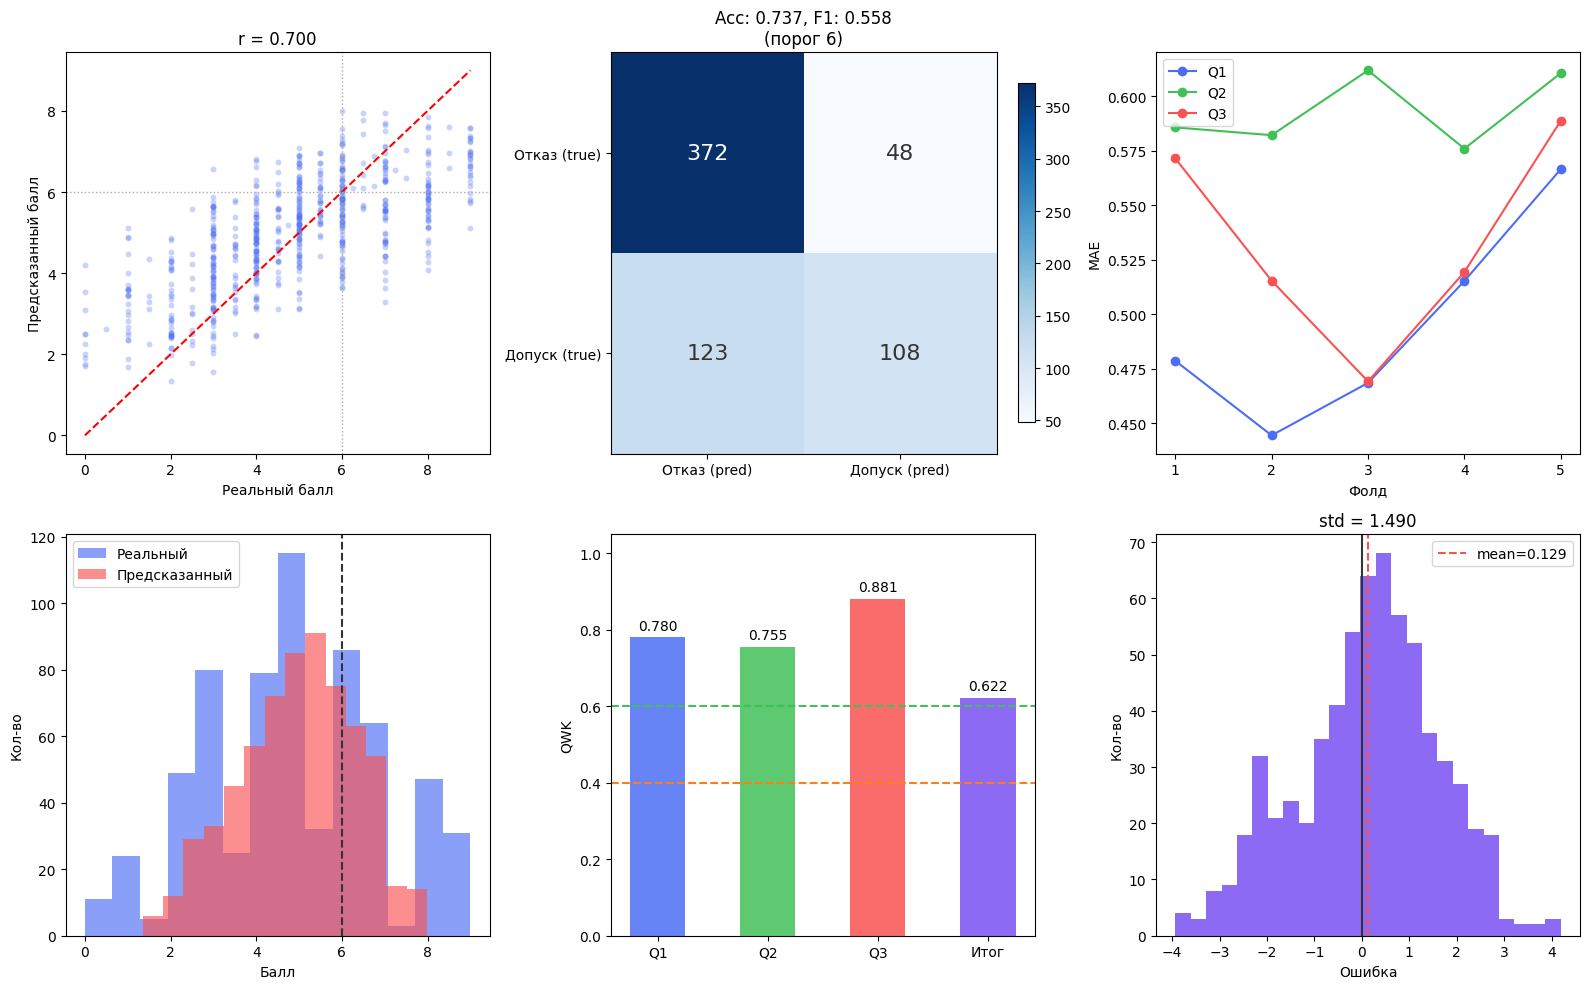

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
ax = axes[0, 0]
ax.scatter(total_true, all_oof, alpha=0.3, s=18, color=colors[0], linewidths=0)
ax.plot([0, 9], [0, 9], "r--", linewidth=1.5)
ax.axhline(threshold, color="#aaa", linestyle=":", linewidth=1)
ax.axvline(threshold, color="#aaa", linestyle=":", linewidth=1)
ax.set_xlabel("Реальный балл")
ax.set_ylabel("Предсказанный балл")
ax.set_title(f"r = {r_total:.3f}")
ax = axes[0, 1]
cm = confusion_matrix(pt, pp)
im = ax.imshow(cm, cmap="Blues", aspect="auto")
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() * 0.6 else "#333"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=16, color=color)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Отказ (pred)", "Допуск (pred)"])
ax.set_yticklabels(["Отказ (true)", "Допуск (true)"])
ax.set_title(f"Acc: {accuracy_score(pt, pp):.3f}, F1: {f1_score(pt, pp):.3f}\n(порог {threshold})")
plt.colorbar(im, ax=ax, fraction=0.04)
ax = axes[0, 2]
for (_, _, q_name), color in zip(questions, colors):
    if q_name in fold_mae_log:
        if isinstance(fold_mae_log[q_name], (int, float)):
            mae_values = [fold_mae_log[q_name]] * fold_out
        else:
            mae_values = fold_mae_log[q_name]

        if len(mae_values) == fold_out:
            ax.plot(range(1, fold_out + 1), mae_values, marker="o", label=q_name.split(":")[0], color=color)
ax.set_xlabel("Фолд")
ax.set_ylabel("MAE")
ax.set_xticks(range(1, fold_out + 1))
ax.legend()
ax = axes[1, 0]
ax.hist(total_true, bins=14, alpha=0.65, label="Реальный", color=colors[0], ec="white")
ax.hist(all_oof, bins=14, alpha=0.65, label="Предсказанный", color=colors[2], ec="white")
ax.axvline(threshold, color="#333", linestyle="--")
ax.set_xlabel("Балл")
ax.set_ylabel("Кол-во")
ax.legend()
ax = axes[1, 1]
q_labels = [q.split(":")[0] for _, _, q in questions] + ["Итог"]
qwk_vals = []

for q_col, s_col, _ in questions:
    y_q = train[s_col].fillna(0).values
    char_v, word_v = tfidf_store[q_col]
    miss_flags_q = train[f"is_missing_{q_col}"]
    Xq = encode(train[q_col], miss_flags_q, char_v, word_v)
    rf, gf, w_ridge, w_gbm = models_final[q_col]
    p = np.clip(w_ridge * rf.predict(Xq) + w_gbm * gf.predict(Xq), 0, 3)
    qwk_vals.append(qwk(y_q, p, 3))
qwk_vals.append(qwk(total_true, all_oof, 9))
bars = ax.bar(q_labels, qwk_vals, color=colors[:4], alpha=0.85, width=0.5)
ax.axhline(0.6, color="#40C057", linestyle="--")
ax.axhline(0.4, color="#FD7E14", linestyle="--")
ax.set_ylim(0, 1.05)
ax.set_ylabel("QWK")
for bar, v in zip(bars, qwk_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center")
ax = axes[1, 2]
residuals = all_oof - total_true
ax.hist(residuals, bins=25, color=colors[3], alpha=0.85, ec="white")
ax.axvline(0, color="#333")
ax.axvline(residuals.mean(), color=colors[2], linestyle="--", label=f"mean={residuals.mean():.3f}")
ax.set_xlabel("Ошибка")
ax.set_ylabel("Кол-во")
ax.set_title(f"std = {residuals.std():.3f}")
ax.legend()
plt.tight_layout()
plt.show()

## 7.5 RuBERT-tiny2 и DeepPavlov





### Получение эмбеддингов

Переводим обычный человеческий текст в понятные для компьютера числовые векторы с помощью токенайзера.


In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [19]:
def get_bert_embeddings(
    texts: list, model_name: str, device, batch_size: int = 32, max_length: int = 256
) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()
    all_embeddings = []
    pad_str = tokenizer.pad_token or "[PAD]"
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        batch = [str(t) if str(t).strip() else pad_str for t in batch]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)
        with torch.no_grad():
            output = model(**encoded)
        cls_embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

In [20]:
def encode_all_questions_bert(
    df: pd.DataFrame, model_name: str, device: str = "cpu"
) -> np.ndarray:
    parts = []
    for q_col in ["q1", "q2", "q3"]:
        emb = get_bert_embeddings(
            df[q_col].tolist(), model_name, batch_size=32, device=device
        )
        parts.append(emb)
    return np.hstack(parts)

### Модель поверх эмбеддингов

Вместо сложного ансамбля мы берем полученные числовые векторы и обучаем на них простую Ridge-регрессию (линейную модель с защитой от переобучения).

Для каждого из трех вопросов настраивается своя независимая модель. Чтобы получить финальную оценку кандидата, мы просто складываем баллы, которые три эти модели поставили за каждый ответ по отдельности.


In [21]:
X_bert_train = encode_all_questions_bert(train, "cointegrated/rubert-tiny2", device)
X_bert_val = encode_all_questions_bert(val, "cointegrated/rubert-tiny2", device)

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
bert_models = {}
bert_oof_total = np.zeros(len(train))
kf_bert = KFold(n_splits=5, shuffle=True, random_state=42)
embedding_dim = 312
for idx, (q_col, s_col, q_name) in enumerate(questions):
    y = train[s_col].fillna(0).values
    start_col = idx * embedding_dim
    end_col = start_col + embedding_dim
    X_q_train = X_bert_train[:, start_col:end_col]
    lengths_train = train[q_col].str.len().values.reshape(-1, 1) / 500.0
    X_q_train = np.hstack([X_q_train, lengths_train])
    oof = np.zeros(len(y))
    best_alphas_list = []
    for fold, (tr_i, val_i) in enumerate(kf_bert.split(X_q_train)):
        fold_inf = KFold(n_splits=3, shuffle=True, random_state=fold)
        best_alpha, best_mae_in = 1.0, 999.0
        for alpha in ridge_alpha:
            inner_maes = []
            for ti, vi in fold_inf.split(X_q_train[tr_i]):
                r = Ridge(alpha=alpha)
                r.fit(X_q_train[tr_i][ti], y[tr_i][ti])
                p = np.clip(r.predict(X_q_train[tr_i][vi]), 0, 3)
                inner_maes.append(mean_absolute_error(y[tr_i][vi], p))
            if np.mean(inner_maes) < best_mae_in:
                best_mae_in, best_alpha = np.mean(inner_maes), alpha
        best_alphas_list.append(best_alpha)
        r = Ridge(alpha=best_alpha)
        r.fit(X_q_train[tr_i], y[tr_i])
        oof[val_i] = np.clip(r.predict(X_q_train[val_i]), 0, 3)

    final_alpha = np.mean(best_alphas_list)
    final_r = Ridge(alpha=final_alpha)
    final_r.fit(X_q_train, y)
    bert_models[q_col] = final_r
    bert_oof_total += oof
    print(f"[{q_name}] RuBERT-Tiny2 QWK: {qwk(y, oof, 3):.3f}")
total_true = train["total"].fillna(0).values
kf_meta = KFold(n_splits=5, shuffle=True, random_state=42)
meta_oof_rounded = np.zeros(len(train))
fold_thresholds = []
for fold, (tr_i, val_i) in enumerate(kf_meta.split(bert_oof_total)):
    def objective_thresholds(trial):
        t0 = trial.suggest_float("t0", 0.1, 1.5)
        t1 = trial.suggest_float("t1", t0 + 0.1, 2.5)
        t2 = trial.suggest_float("t2", t1 + 0.1, 3.5)
        t3 = trial.suggest_float("t3", t2 + 0.1, 4.5)
        t4 = trial.suggest_float("t4", t3 + 0.1, 5.5)
        t5 = trial.suggest_float("t5", t4 + 0.1, 6.5)
        t6 = trial.suggest_float("t6", t5 + 0.1, 7.5)
        t7 = trial.suggest_float("t7", t6 + 0.1, 8.5)
        thresholds = [t0, t1, t2, t3, t4, t5, t6, t7]
        preds_digitized = np.digitize(bert_oof_total[tr_i], thresholds)
        return qwk(total_true[tr_i], preds_digitized, max_score=9)

    study_t = optuna.create_study(direction="maximize")
    study_t.optimize(objective_thresholds, n_trials=100)
    best_t = sorted(list(study_t.best_params.values()))
    fold_thresholds.append(best_t)
    meta_oof_rounded[val_i] = np.digitize(bert_oof_total[val_i], best_t)

best_thresholds = np.mean(fold_thresholds, axis=0)
print(f"Пороги: {[round(t, 2) for t in best_thresholds]}")
print(f"QWK{qwk(total_true, meta_oof_rounded, 9):.3f}")

[Q1: Почему именно вы?] RuBERT-Tiny2 QWK: 0.551
[Q2: Применение знаний] RuBERT-Tiny2 QWK: 0.510


[I 2026-06-30 07:31:36,073] A new study created in memory with name: no-name-f4157954-d956-4712-97fe-4b4cb40bdcb4
[I 2026-06-30 07:31:36,082] Trial 0 finished with value: 0.6975600764045372 and parameters: {'t0': 1.420809442790886, 't1': 2.1325832312652167, 't2': 2.4251483045959628, 't3': 4.199488765252206, 't4': 4.786617553818448, 't5': 4.908353988278427, 't6': 5.328638836117491, 't7': 6.238403705432326}. Best is trial 0 with value: 0.6975600764045372.
[I 2026-06-30 07:31:36,090] Trial 1 finished with value: 0.644192256341789 and parameters: {'t0': 0.5045451555879947, 't1': 1.2502151373648613, 't2': 3.370613268065715, 't3': 3.7188857009661325, 't4': 4.422739447616734, 't5': 4.602525291168822, 't6': 7.168033837832798, 't7': 7.58612517514639}. Best is trial 0 with value: 0.6975600764045372.
[I 2026-06-30 07:31:36,097] Trial 2 finished with value: 0.6404739990796133 and parameters: {'t0': 1.030423416021573, 't1': 1.1996803525768995, 't2': 2.5441701564997494, 't3': 4.4228882623999155, 't4

[Q3: Задача сверх обязанностей] RuBERT-Tiny2 QWK: 0.623


[I 2026-06-30 07:31:36,305] Trial 15 finished with value: 0.7167641429472341 and parameters: {'t0': 1.1971951609447302, 't1': 2.465242290239363, 't2': 3.2270240463480744, 't3': 4.268064706966494, 't4': 4.683818878635263, 't5': 5.3987782302261085, 't6': 6.4039521168216575, 't7': 6.911757587274036}. Best is trial 14 with value: 0.7276409516271707.
[I 2026-06-30 07:31:36,329] Trial 16 finished with value: 0.7079178092991041 and parameters: {'t0': 0.85480661234749, 't1': 2.498399379340458, 't2': 3.20446324410588, 't3': 4.21890195029919, 't4': 4.595810043108524, 't5': 5.4431204746350215, 't6': 6.4952106471513735, 't7': 7.031560255690954}. Best is trial 14 with value: 0.7276409516271707.
[I 2026-06-30 07:31:36,355] Trial 17 finished with value: 0.7051290698682804 and parameters: {'t0': 1.2406333910966263, 't1': 2.365788760633623, 't2': 3.223575108187176, 't3': 4.012157704653665, 't4': 4.411687336278492, 't5': 5.583910264538148, 't6': 6.486764706044586, 't7': 7.029089326352327}. Best is trial

Пороги: [np.float64(1.17), np.float64(2.4), np.float64(3.26), np.float64(4.17), np.float64(4.66), np.float64(5.38), np.float64(5.95), np.float64(6.53)]
QWK0.709


### DeepPavlov/rubert-base-cased


In [23]:
X_bert_base_train = encode_all_questions_bert(train, "DeepPavlov/rubert-base-cased", device)
X_bert_base_val = encode_all_questions_bert(val, "DeepPavlov/rubert-base-cased", device)

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

...

[transformers] BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
kf_base = KFold(n_splits=5, shuffle=True, random_state=42)
base_oof_total = np.zeros(len(train))
base_models = {}
for q_col, s_col, q_name in questions:
    y = train[s_col].fillna(0).values
    oof = np.zeros(len(y))
    best_alphas_list = []
    for fold, (tr_i, val_i) in enumerate(kf_base.split(X_bert_base_train)):
        fold_inf = KFold(n_splits=3, shuffle=True, random_state=fold)
        best_alpha, best_mae_in = 1.0, 999.0
        for alpha in ridge_alpha:
            inner_maes = []
            for ti, vi in fold_inf.split(X_bert_base_train[tr_i]):
                r = Ridge(alpha=alpha)
                r.fit(X_bert_base_train[tr_i][ti], y[tr_i][ti])
                p = np.clip(r.predict(X_bert_base_train[tr_i][vi]), 0, 3)
                inner_maes.append(mean_absolute_error(y[tr_i][vi], p))
            if np.mean(inner_maes) < best_mae_in:
                best_mae_in, best_alpha = np.mean(inner_maes), alpha
        best_alphas_list.append(best_alpha)
        r = Ridge(alpha=best_alpha)
        r.fit(X_bert_base_train[tr_i], y[tr_i])
        oof[val_i] = np.clip(r.predict(X_bert_base_train[val_i]), 0, 3)
    final_alpha = np.mean(best_alphas_list)
    final_r = Ridge(alpha=final_alpha)
    final_r.fit(X_bert_base_train, y)
    base_models[q_col] = final_r
    base_oof_total += oof
    print(f"{q_name} - MAE: {mean_absolute_error(y, oof):.3f}, QWK: {qwk(y, oof, 3):.3f}")
total_true = train["total"].fillna(0).values
kf_meta = KFold(n_splits=5, shuffle=True, random_state=42)
meta_oof_rounded = np.zeros(len(train))
fold_thresholds = []
for fold, (tr_i, val_i) in enumerate(kf_meta.split(base_oof_total)):
    def objective_thresholds(trial):
        t0 = trial.suggest_float("t0", 0.1, 1.5)
        t1 = trial.suggest_float("t1", t0 + 0.1, 2.5)
        t2 = trial.suggest_float("t2", t1 + 0.1, 3.5)
        t3 = trial.suggest_float("t3", t2 + 0.1, 4.5)
        t4 = trial.suggest_float("t4", t3 + 0.1, 5.5)
        t5 = trial.suggest_float("t5", t4 + 0.1, 6.5)
        t6 = trial.suggest_float("t6", t5 + 0.1, 7.5)
        t7 = trial.suggest_float("t7", t6 + 0.1, 8.5)
        thresholds = [t0, t1, t2, t3, t4, t5, t6, t7]
        preds_digitized = np.digitize(base_oof_total[tr_i], thresholds)
        return qwk(total_true[tr_i], preds_digitized, max_score=9)
    study_t = optuna.create_study(direction="maximize")
    study_t.optimize(objective_thresholds, n_trials=100)
    best_t = sorted(list(study_t.best_params.values()))
    fold_thresholds.append(best_t)
    meta_oof_rounded[val_i] = np.digitize(base_oof_total[val_i], best_t)
best_thresholds = np.mean(fold_thresholds, axis=0)
print(f"Пороги: {[round(t, 2) for t in best_thresholds]}")
print(f"MAE: {mean_absolute_error(total_true, base_oof_total):.3f}, RMSE: {mean_squared_error(total_true, base_oof_total)**0.5:.3f}, ЧЕСТНЫЙ QWK НА КРОСС-ВАЛИДАЦИИ: {qwk(total_true, meta_oof_rounded, 9):.3f}")

Q1: Почему именно вы? - MAE: 0.507, QWK: 0.482
Q2: Применение знаний - MAE: 0.553, QWK: 0.461


[I 2026-06-30 07:32:30,562] A new study created in memory with name: no-name-212f4bdf-5b89-4cf9-a2f0-a22d4f27c854
[I 2026-06-30 07:32:30,571] Trial 0 finished with value: 0.5215959713344954 and parameters: {'t0': 0.44548831575764314, 't1': 1.5101033649862274, 't2': 1.7543195914674081, 't3': 2.7833519655916317, 't4': 4.773640343955407, 't5': 5.995642472351603, 't6': 7.378101248324685, 't7': 8.047252106176503}. Best is trial 0 with value: 0.5215959713344954.
[I 2026-06-30 07:32:30,579] Trial 1 finished with value: 0.27755046142683126 and parameters: {'t0': 0.34223850661161415, 't1': 0.6818755338689898, 't2': 0.8578175683594059, 't3': 1.327967901478968, 't4': 3.0581222667844687, 't5': 3.1666633911036306, 't6': 7.186026462312712, 't7': 7.365245717397378}. Best is trial 0 with value: 0.5215959713344954.
[I 2026-06-30 07:32:30,587] Trial 2 finished with value: 0.3540994134415758 and parameters: {'t0': 1.2404136592270278, 't1': 1.515663441702884, 't2': 1.8271945050158922, 't3': 2.079138398181

Q3: Задача сверх обязанностей - MAE: 0.528, QWK: 0.592


[I 2026-06-30 07:32:30,771] Trial 14 finished with value: 0.6685470580054638 and parameters: {'t0': 1.0686834178647158, 't1': 2.160988116053325, 't2': 3.2660774618985307, 't3': 3.7272494534581004, 't4': 5.103157830486045, 't5': 5.484546099491401, 't6': 5.653155368241716, 't7': 5.772651826996686}. Best is trial 14 with value: 0.6685470580054638.
[I 2026-06-30 07:32:30,792] Trial 15 finished with value: 0.6815711908986612 and parameters: {'t0': 1.0103697431409533, 't1': 2.1464217387085656, 't2': 3.2622046578125197, 't3': 3.686907500012015, 't4': 5.181382695063293, 't5': 5.530092250962111, 't6': 5.8629792350182335, 't7': 6.739662563620133}. Best is trial 15 with value: 0.6815711908986612.
[I 2026-06-30 07:32:30,817] Trial 16 finished with value: 0.6772160919367785 and parameters: {'t0': 0.9827798529543597, 't1': 2.093557704567235, 't2': 3.2127180341656705, 't3': 3.62021589289702, 't4': 5.142882698650326, 't5': 5.466837242956177, 't6': 5.878908414144277, 't7': 6.83569623034038}. Best is tr

Пороги: [np.float64(1.16), np.float64(2.26), np.float64(3.26), np.float64(4.02), np.float64(4.73), np.float64(5.19), np.float64(5.75), np.float64(6.76)]
MAE: 1.165, RMSE: 1.479, ЧЕСТНЫЙ QWK НА КРОСС-ВАЛИДАЦИИ: 0.684


### Сравнение всех подходов

In [36]:
results = []
total_true = train["total"].fillna(0).values

if "all_oof_tfidf" in locals() or "all_oof_tfidf" in globals():
    all_oof = all_oof_tfidf

results.append(
    {
        "Модель": "TF-IDF + GBM (baseline)",
        "MAE": round(mean_absolute_error(total_true, all_oof), 3),
        "RMSE": round(mean_squared_error(total_true, all_oof) ** 0.5, 3),
        "QWK": round(qwk(total_true, all_oof, 9), 3),
    }
)

if "bert_oof_rounded" in locals() or "bert_oof_rounded" in globals():
    tiny2_qwk_input = bert_oof_rounded
elif "meta_oof_rounded" in locals() or "meta_oof_rounded" in globals():
    tiny2_qwk_input = meta_oof_rounded
elif "best_thresholds_tiny" in locals() or "best_thresholds_tiny" in globals():
    tiny2_qwk_input = np.digitize(bert_oof_total, best_thresholds_tiny)
else:
    tiny2_qwk_input = np.digitize(bert_oof_total, best_thresholds)

results.append(
    {
        "Модель": "rubert-tiny2 + Ridge",
        "MAE": round(mean_absolute_error(total_true, bert_oof_total), 3),
        "RMSE": round(mean_squared_error(total_true, bert_oof_total) ** 0.5, 3),
        "QWK": round(qwk(total_true, tiny2_qwk_input, 9), 3),
    }
)

if "base_oof_rounded" in locals() or "base_oof_rounded" in globals():
    base_qwk_input = base_oof_rounded
elif "best_thresholds_base" in locals() or "best_thresholds_base" in globals():
    base_qwk_input = np.digitize(base_oof_total, best_thresholds_base)
else:
    base_qwk_input = np.digitize(base_oof_total, best_thresholds)

results.append(
    {
        "Модель": "rubert-base-cased + Ridge",
        "MAE": round(mean_absolute_error(total_true, base_oof_total), 3),
        "RMSE": round(mean_squared_error(total_true, base_oof_total) ** 0.5, 3),
        "QWK": round(qwk(total_true, base_qwk_input, 9), 3),
    }
)

cmp_df = pd.DataFrame(results).set_index("Модель")
print(cmp_df)


                             MAE   RMSE    QWK
Модель                                        
TF-IDF + GBM (baseline)    1.197  1.496  0.622
rubert-tiny2 + Ridge       1.120  1.414  0.684
rubert-base-cased + Ridge  1.165  1.479  0.697


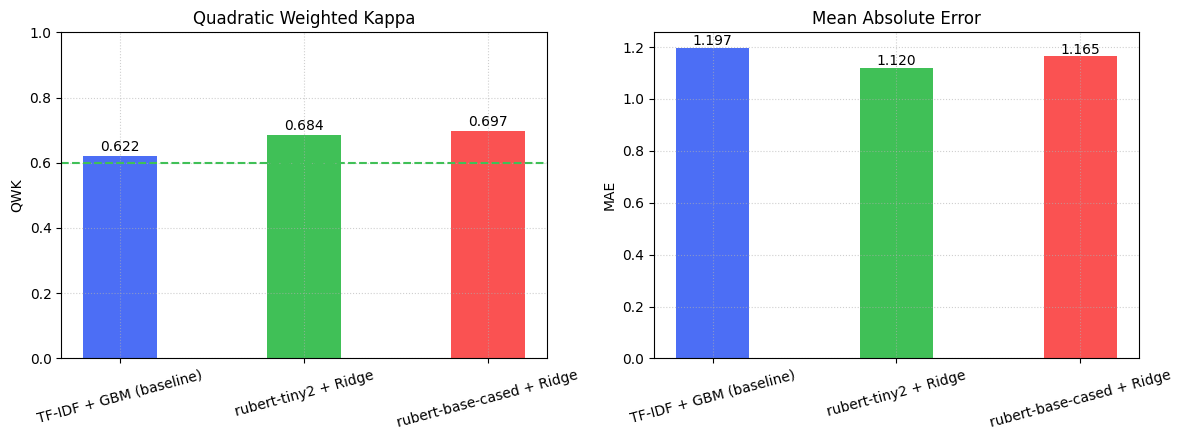

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
model_names = cmp_df.index.tolist()
bars_qwk = axes[0].bar(
    model_names, cmp_df["QWK"], color=colors[: len(model_names)], width=0.4
)
axes[0].axhline(0.6, color="#40C057", linestyle="--")
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("QWK")
axes[0].set_title("Quadratic Weighted Kappa")
axes[0].grid(True, alpha=0.6, linestyle=":")
for bar, v in zip(bars_qwk, cmp_df["QWK"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center"
    )
axes[0].tick_params(axis="x", rotation=15)
bars_mae = axes[1].bar(
    model_names, cmp_df["MAE"], color=colors[: len(model_names)], width=0.4
)
axes[1].set_ylabel("MAE")
axes[1].set_title("Mean Absolute Error")
axes[1].grid(True, alpha=0.6, linestyle=":")
for bar, v in zip(bars_mae, cmp_df["MAE"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center"
    )
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

In [29]:
best_model = "rubert-tiny2"
X_val_final = X_bert_val
final_models_bert = bert_models
embedding_dim = 312
bert_val_preds = {}

In [30]:
for idx, (q_col, s_col, q_name) in enumerate(questions):
    start_col = idx * embedding_dim
    end_col = start_col + embedding_dim
    X_q_val = X_val_final[:, start_col:end_col]

    lengths_val = val[q_col].str.len().values.reshape(-1, 1) / 500.0
    X_q_val_full = np.hstack([X_q_val, lengths_val])

    bert_val_preds[s_col] = np.clip(final_models_bert[q_col].predict(X_q_val_full), 0, 3)

predictions_bert = pd.DataFrame(
    {
        "id": val["id"],
        "pred_score1": np.round(bert_val_preds["score1"], 2),
        "pred_score2": np.round(bert_val_preds["score2"], 2),
        "pred_score3": np.round(bert_val_preds["score3"], 2),
    }
)
predictions_bert["pred_total"] = (predictions_bert["pred_score1"]+ predictions_bert["pred_score2"]+ predictions_bert["pred_score3"]).round(2)
predictions_bert["pass"] = ( predictions_bert["pred_total"] >= threshold).astype(int)
predictions_bert.to_excel(f"predictions_{best_model}.xlsx", index=False)
predictions_bert.head(10)

,id,pred_score1,pred_score2,pred_score3,pred_total,pass
0,val_0,1.63,2.05,1.87,5.55,0
1,val_1,1.60,0.71,2.27,4.58,0
2,val_2,1.53,2.14,2.10,5.77,0
3,val_3,1.73,2.18,2.03,5.94,0
4,val_4,1.39,2.14,2.14,5.67,0
5,val_5,0.86,1.69,2.34,4.89,0
6,val_6,2.08,2.53,2.30,6.91,1
7,val_7,1.77,1.96,2.39,6.12,1
8,val_8,1.99,2.58,2.39,6.96,1
9,val_9,0.66,0.93,2.28,3.87,0


## 8. Предсказание на итоговой выборке


In [32]:
val_preds = {}
embedding_dim = 312

for idx, (q_col, s_col, _) in enumerate(questions):
    start_col = idx * embedding_dim
    end_col = start_col + embedding_dim
    X_q_val = X_bert_val[:, start_col:end_col]
    lengths_val = val[q_col].str.len().values.reshape(-1, 1) / 500.0
    X_q_val_full = np.hstack([X_q_val, lengths_val])
    val_preds[s_col] = np.clip(bert_models[q_col].predict(X_q_val_full), 0, 3)

predictions = pd.DataFrame({
    "id": val["id"],
    "pred_score1": np.round(val_preds["score1"], 2),
    "pred_score2": np.round(val_preds["score2"], 2),
    "pred_score3": np.round(val_preds["score3"], 2),
})
predictions["pred_total"] = (predictions["pred_score1"] + predictions["pred_score2"] + predictions["pred_score3"]).round(2)
predictions["pass"] = (predictions["pred_total"] >= threshold).astype(int)
print(f"Статистика предсказаний {len(predictions)}")
print(predictions["pred_total"].describe().round(2).rename("pred_total").to_string())
print(f"Прошло порог (≥ {threshold}): {predictions['pass'].mean():.1%}  "f"({predictions['pass'].sum()} из {len(predictions)})")
predictions.head(6)

Статистика предсказаний 151
count    151.00
mean       4.94
std        1.39
min        0.79
25%        3.84
50%        5.22
75%        5.94
max        7.46
Прошло порог (≥ 6): 24.5%  (37 из 151)


,id,pred_score1,pred_score2,pred_score3,pred_total,pass
0,val_0,1.63,2.05,1.87,5.55,0
1,val_1,1.60,0.71,2.27,4.58,0
2,val_2,1.53,2.14,2.10,5.77,0
3,val_3,1.73,2.18,2.03,5.94,0
4,val_4,1.39,2.14,2.14,5.67,0
5,val_5,0.86,1.69,2.34,4.89,0


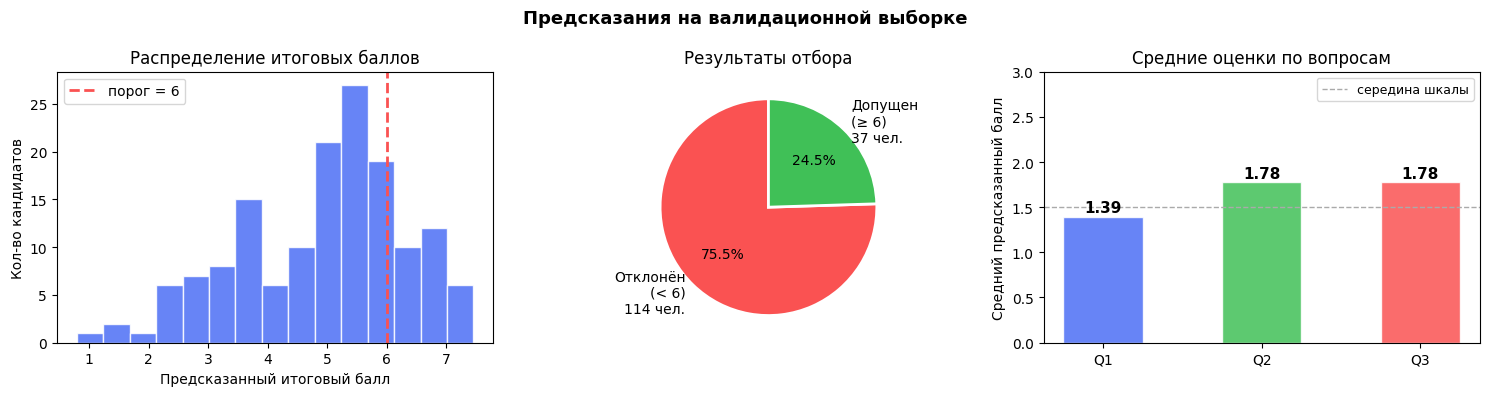

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Предсказания на валидационной выборке",
             fontsize=13, fontweight="bold")
axes[0].hist(predictions["pred_total"], bins=15, color=colors[0],
             alpha=0.85, edgecolor="white")
axes[0].axvline(threshold, color=colors[2], linestyle="--",
                linewidth=2, label=f"порог = {threshold}")
axes[0].set_xlabel("Предсказанный итоговый балл")
axes[0].set_ylabel("Кол-во кандидатов")
axes[0].set_title("Распределение итоговых баллов")
axes[0].legend()
admitted = predictions["pass"].value_counts().sort_index()
labels   = [f"Отклонён\n(< {threshold})", f"Допущен\n(≥ {threshold})"]
axes[1].pie(admitted.values,
            labels=[f"{l}\n{v} чел." for l, v in zip(labels, admitted.values)],
            colors=[colors[2], colors[1]], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Результаты отбора")
q_labels_short = ["Q1", "Q2", "Q3"]
avg_scores = [predictions["pred_score1"].mean(),
              predictions["pred_score2"].mean(),
              predictions["pred_score3"].mean()]
bars = axes[2].bar(q_labels_short, avg_scores,
                   color=colors[:3], alpha=0.85, edgecolor="white", width=0.5)
axes[2].set_ylim(0, 3)
axes[2].axhline(1.5, color="#aaa", linestyle="--", linewidth=1, label="середина шкалы")
axes[2].set_ylabel("Средний предсказанный балл")
axes[2].set_title("Средние оценки по вопросам")
for bar, v in zip(bars, avg_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.05,
                 f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")
axes[2].legend(fontsize=9)
plt.tight_layout()
plt.show()

In [34]:
predictions.to_excel('val_predictions.xlsx', index=False)